In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd

from dd_kable_analysis.config_loader import load_config

In [3]:
cfg = load_config()

In [8]:
pauli_rois = cfg.masks_dir / 'pauli_subcort_rois_neurovault_collection_3145'
group_mask = (
    cfg.masks_dir / 'assess_subject_bold_dropout/group_mask_intersection_30pct.nii.gz'
)

In [ ]:
from pathlib import Path

from nilearn.image import resample_to_img

# ---- inputs you already have as Path objects ----
# pauli_rois = Path("...")   # dir with the CIT168toMNI152_prob_atlas_bilat_1mm__(volume X).nii.gz files
# group_mask = Path("...")   # your group mask nifti

# ---- ROI name mapping (your list; volume 1 corresponds to index 0) ----
ROI_NAMES = [
    'Pu',
    'Ca',
    'NAC',
    'EXA',
    'GPe',
    'GPi',
    'SNc',
    'RN',
    'SNr',
    'PBP',
    'VTA',
    'VeP',
    'HN',
    'HTH',
    'MN',
    'STH',
]

thr = 0.50  # probability threshold


In [10]:
# ---- find the 16 volume files ----
vol_files = {}
for p in pauli_rois.glob('CIT168toMNI152_prob_atlas_bilat_1mm__*.nii.gz'):
    s = p.name
    if '(volume ' not in s:
        continue
    vol = int(s.split('(volume ', 1)[1].split(')', 1)[0].strip())
    vol_files[vol] = p

missing = sorted(set(range(1, 17)) - set(vol_files))
if missing:
    raise FileNotFoundError(
        f'Missing volume files: {missing}\nFound: {sorted(vol_files)}'
    )


In [12]:
# ---- load group mask (defines target grid/space) ----
mask_img = nib.load(str(group_mask))
mask_bool = mask_img.get_fdata().astype(bool)

In [13]:
# ---- build label atlas + overlap check ----
label_data = np.zeros(mask_img.shape[:3], dtype=np.int16)  # 0=background, 1..16=ROIs
hit_count = np.zeros(
    mask_img.shape[:3], dtype=np.uint8
)  # how many ROIs claim each voxel
roi_voxels = {}

# resample+threshold each ROI volume onto mask grid
roi_masks = {}  # store to do pairwise overlap reporting if needed
for vol in range(1, 17):
    prob_native = nib.load(str(vol_files[vol]))
    prob_rs = resample_to_img(
        prob_native,
        mask_img,
        interpolation='continuous',
        force_resample=True,
        copy_header=True,
    )
    prob = prob_rs.get_fdata().astype(np.float32)

    m = (prob >= thr) & mask_bool
    roi_masks[vol] = m
    roi_voxels[vol] = int(m.sum())
    hit_count[m] += 1


In [14]:
# overlap summary
n_overlap_vox = int((hit_count >= 2).sum())
print(f'threshold={thr} | overlap voxels (>=2 ROIs): {n_overlap_vox}')


threshold=0.5 | overlap voxels (>=2 ROIs): 0


In [15]:
# build final label image; if overlap exists, assign by max-prob winner at each voxel
# (this guarantees non-overlap, and is usually what you want for a single-label atlas)
prob_stack = np.zeros((16,) + mask_img.shape[:3], dtype=np.float32)
for vol in range(1, 17):
    prob_native = nib.load(str(vol_files[vol]))
    prob_rs = resample_to_img(
        prob_native,
        mask_img,
        interpolation='continuous',
        force_resample=True,
        copy_header=True,
    )
    prob = prob_rs.get_fdata().astype(np.float32)
    prob_stack[vol - 1] = prob

# apply threshold + mask: probabilities below thr are treated as 0 (no claim)
prob_stack[:, ~mask_bool] = 0.0
prob_stack[prob_stack < thr] = 0.0

winner = np.argmax(prob_stack, axis=0) + 1  # 1..16
maxprob = np.max(prob_stack, axis=0)
label_data[maxprob > 0] = winner[maxprob > 0]  # else stays 0


In [18]:
# ---- save outputs next to the input directory ----
out_base = pauli_rois / f'pauli_roi_atlas_thr{thr:.2f}_to-groupmask'
atlas_path = Path(str(out_base) + '.nii.gz')
labels_path = Path(str(out_base) + '_labels.tsv')

atlas_img = nib.Nifti1Image(label_data, affine=mask_img.affine, header=mask_img.header)
atlas_img.set_data_dtype(np.int16)
nib.save(atlas_img, str(atlas_path))
print('wrote:', atlas_path)

# label key (easy to read with pandas.read_csv(..., sep="\t"))
lines = ['label\tname\tcit168_volume']
for vol in range(1, 17):
    lines.append(f'{vol}\t{ROI_NAMES[vol - 1]}\t{vol}')
labels_path.write_text('\n'.join(lines) + '\n')
print('wrote:', labels_path)

# quick per-ROI voxel counts (after thresholding, before winner-take-all)
for vol in range(1, 17):
    print(f'{vol:2d}\t{ROI_NAMES[vol - 1]:>4s}\tvox={roi_voxels[vol]}')

wrote: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145/pauli_roi_atlas_thr0.50_to-groupmask.nii.gz
wrote: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145/pauli_roi_atlas_thr0.50_to-groupmask_labels.tsv
 1	  Pu	vox=1655
 2	  Ca	vox=1399
 3	 NAC	vox=122
 4	 EXA	vox=35
 5	 GPe	vox=221
 6	 GPi	vox=123
 7	 SNc	vox=32
 8	  RN	vox=92
 9	 SNr	vox=69
10	 PBP	vox=14
11	 VTA	vox=2
12	 VeP	vox=19
13	  HN	vox=10
14	 HTH	vox=183
15	  MN	vox=23
16	 STH	vox=39


## Trying to double check the labels we found

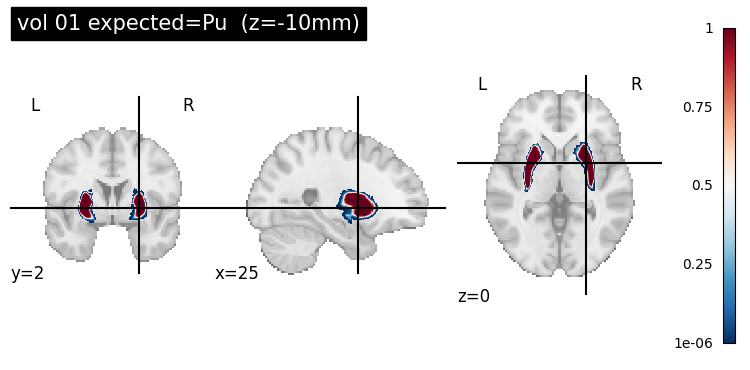

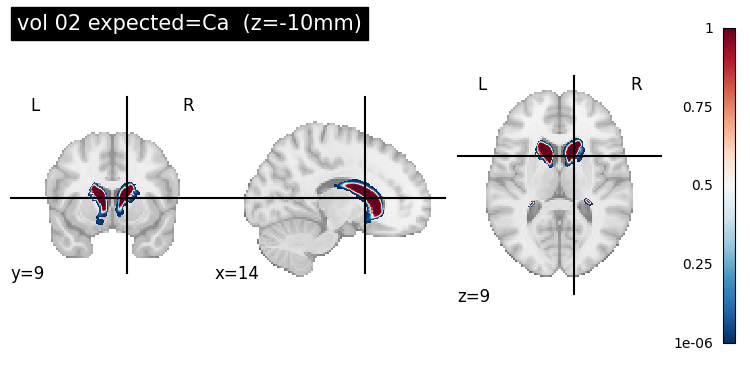

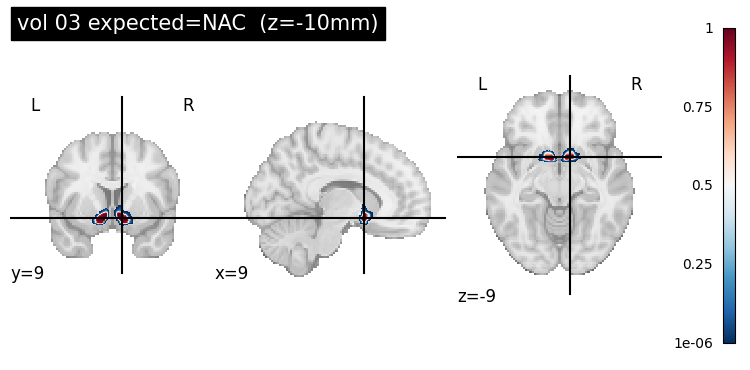

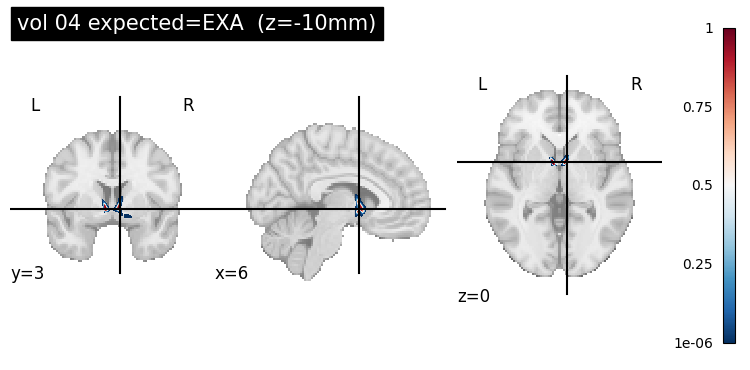

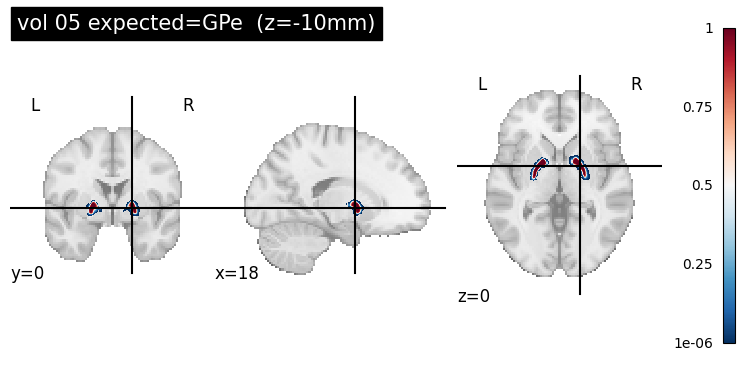

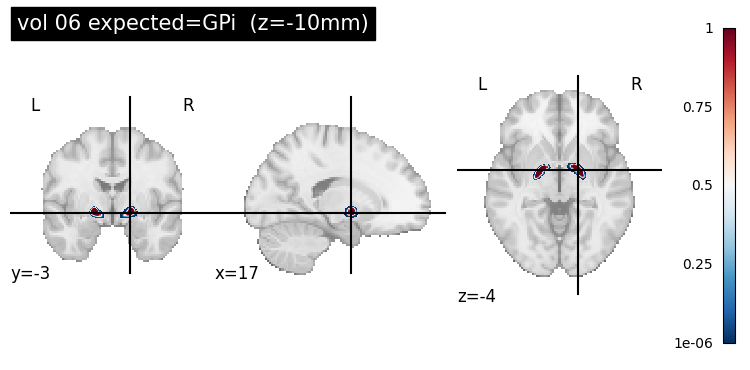

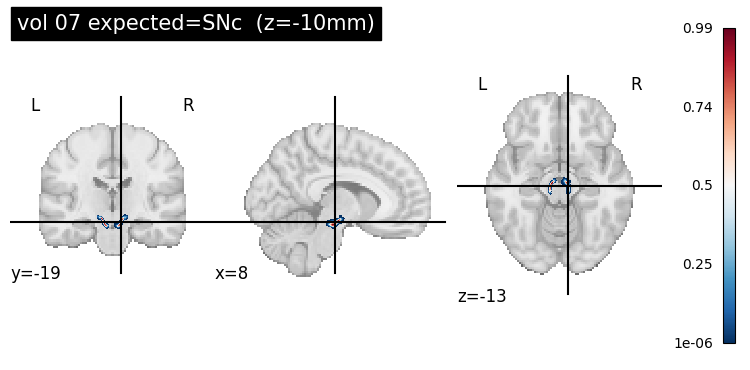

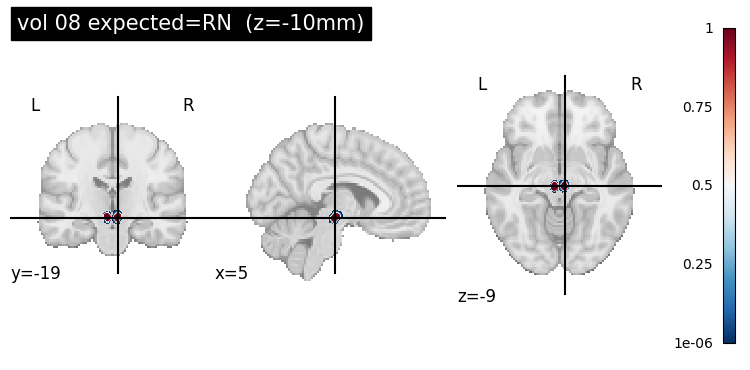

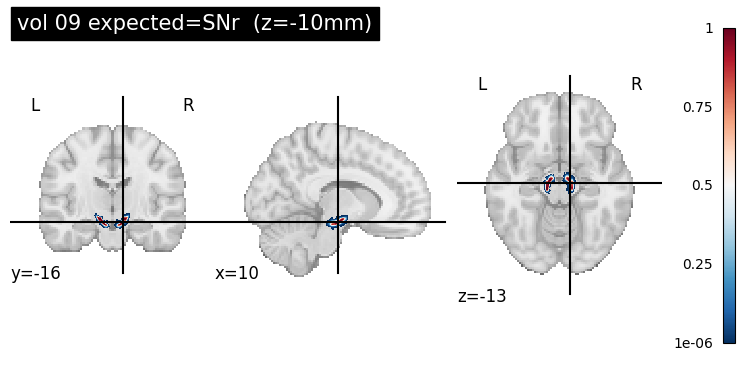

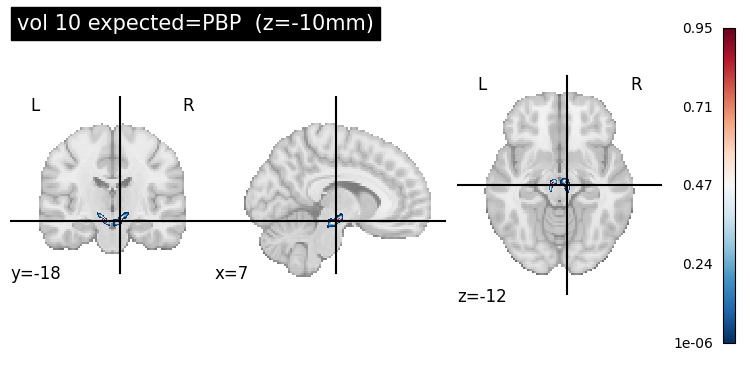

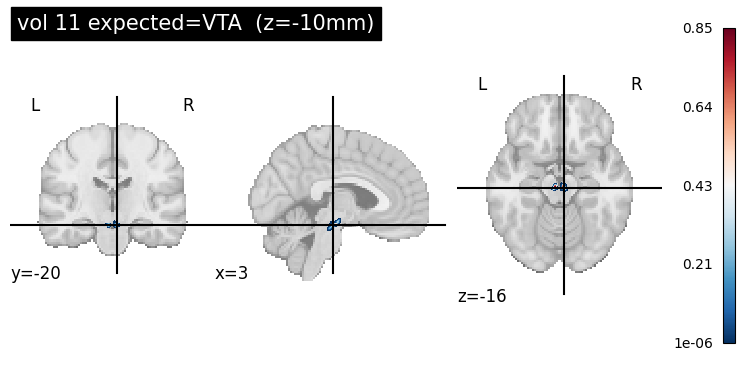

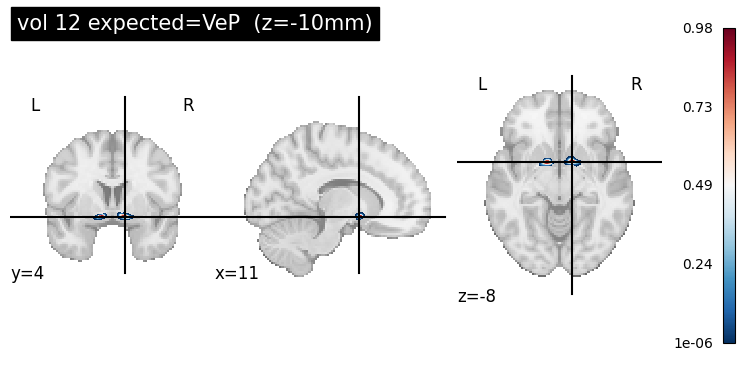

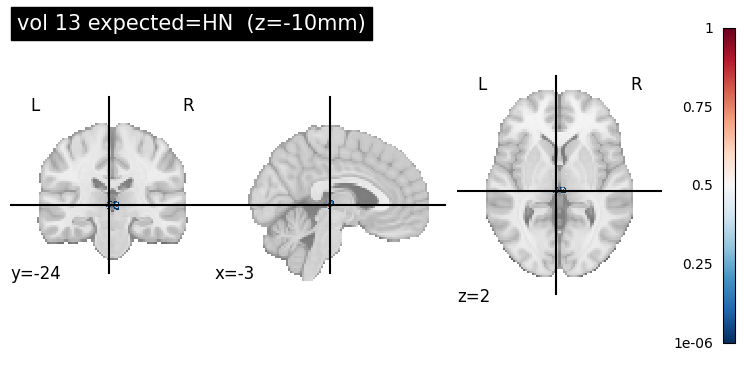

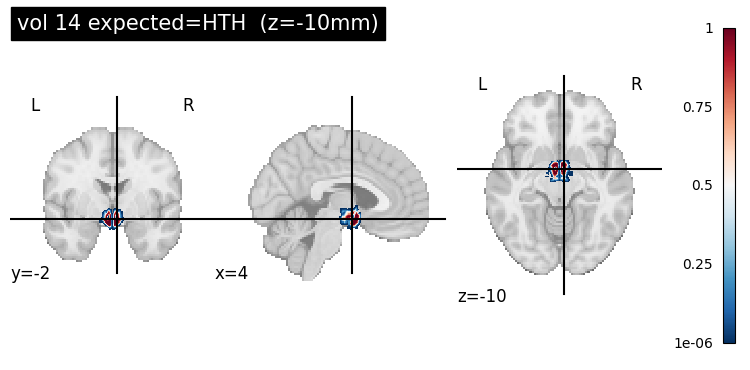

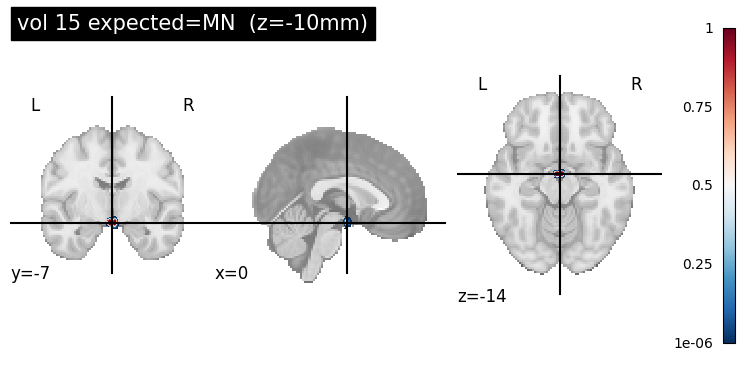

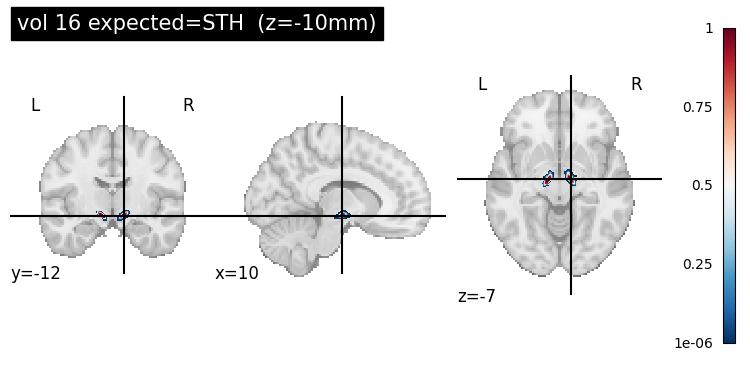

In [24]:
from nilearn.plotting import plot_stat_map

z = -10  # mm

# map volume number -> filepath
vol_files = {}
for p in pauli_rois.glob('CIT168toMNI152_prob_atlas_bilat_1mm__*.nii.gz'):
    s = p.name
    if '(volume ' not in s:
        continue
    vol = int(s.split('(volume ', 1)[1].split(')', 1)[0].strip())
    vol_files[vol] = p

missing = sorted(set(range(1, 17)) - set(vol_files))
if missing:
    raise FileNotFoundError(f'Missing volume files: {missing}')

for vol in range(1, 17):
    roi_name = ROI_NAMES[vol - 1]
    p = vol_files[vol]

    plot_stat_map(
        str(p),  # pass path string; nilearn loads internally
        title=f'vol {vol:02d} expected={roi_name}  (z={z}mm)',
        colorbar=True,  # useful for prob maps
    )
    plt.show()